# 01, Exploratory Data Analysis
**Multimodal Pain Assessment** · PSU AI 570 · Owner: _Jonathan_

Goal of this notebook: understand what we're actually working with before building anything. The headline is in `docs/dataset-notes.md`, but the numbers below are generated live so they can't go stale.

> One notebook, one owner, please don't edit this one directly; the JSON doesn't merge. Open an issue or factor changes into `src/painnet/`.

In [1]:
# --- setup -------------------------------------------------------------------
# On Kaggle, uncomment to pull the package from our private repo:
# from kaggle_secrets import UserSecretsClient
# tok = UserSecretsClient().get_secret("GH_TOKEN")
# !pip install -q git+https://{tok}@github.com/RM-28/multimodal-pain-assesment.git

import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hush the oneDNN chatter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from painnet import config, data, windows, splits, models, evaluate, plots

plots.use_style()
print(config.describe())


painnet | env=local | data=found | /Users/jmill/coding/github/psuai570/project/multimodal-pain-assesment/data/raw/PhysioPain Dataset/Multimodal Pain Dataset


## The dataset in one frame

Because every participant carries a single label for their whole recording, the **subject** is the unit of analysis, not the row, not the window.

In [2]:
subj = data.subject_table()
print(f"subjects: {len(subj)}")
subj.head(10)

subjects: 83


,pain_type,n_seconds,age,gender,self_reported_type,severity,severity_ord,label_disagrees
id,,,,,,,,
S004,headache,1196,23.0,Male,Headache,Moderate,2,False
S005,headache,1197,24.0,Female,Headache,Moderate,2,False
S006,back_pain,1197,NaN,Female,Back/neck/waist pain,Severe,3,False
S008,headache,1209,24.0,Male,Headache,Moderate,2,False
S009,headache,1201,23.0,Male,Headache,Not severe at all,0,False
S010,headache,1202,23.0,Female,Headache,Severe,3,False
S011,headache,1206,25.0,Male,Headache,Mild,1,False
S012,no_pain,1263,21.0,Female,No pain,Not severe at all,0,False
S013,back_pain,1184,52.0,Female,Back/neck/waist pain,Mild,1,False


## Is the label really constant per subject?

This is the assumption the whole design rests on, so let's check it rather than trust it.

In [3]:
df = data.load_raw_eeg()
varying = df.groupby(config.SUBJECT_COL)[config.LABEL_COL].nunique()
print(f"rows: {len(df):,}")
print(f"subjects: {varying.size}")
print(f"subjects with more than one pain_type: {(varying > 1).sum()}")
# -> 0. so a window's label is decided entirely by whose recording it came from.

rows: 101,356
subjects: 83
subjects with more than one pain_type: 0


## Class balance, subjects vs rows

Row counts look like a lot of data. They aren't.

In [4]:
bal = pd.DataFrame({
    "subjects": subj.pain_type.value_counts(),
    "rows": df.pain_type.value_counts(),
})
bal["subj_pct"] = (100 * bal.subjects / bal.subjects.sum()).round(1)
print(bal)
print(f"\nmajority-class baseline: {bal.subjects.max() / bal.subjects.sum():.3f}")

                subjects   rows  subj_pct
pain_type                                
headache              30  36492      36.1
back_pain             28  33766      33.7
no_pain               15  18016      18.1
menstrual_pain        10  13082      12.0

majority-class baseline: 0.361


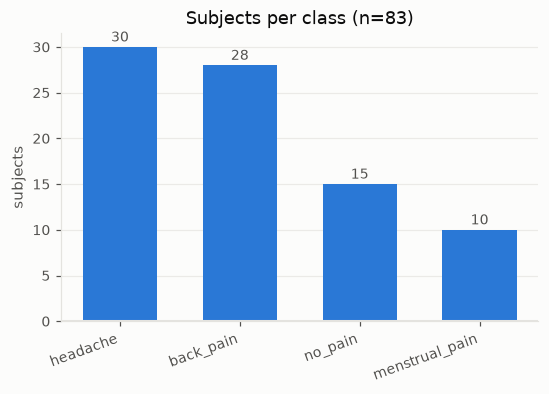

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
plots.subject_balance(bal.subjects.to_dict(), ax=ax)
plt.show()

## Recording length

Ragged recordings, so we window rather than pad.

count      83.0
mean     1221.2
std       118.8
min       740.0
25%      1203.5
50%      1228.0
75%      1255.0
max      1826.0
dtype: float64


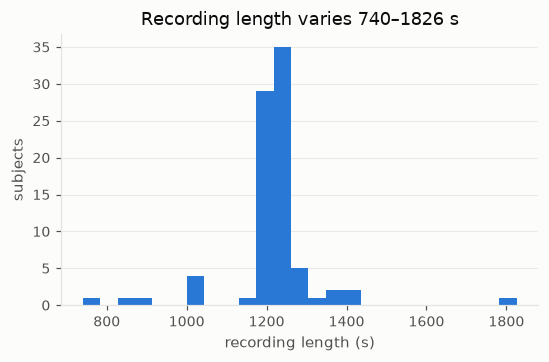

In [6]:
lens = df.groupby(config.SUBJECT_COL).size()
print(lens.describe().round(1))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.hist(lens, bins=25, color=plots.SERIES[0])
ax.set_xlabel("recording length (s)"); ax.set_ylabel("subjects")
ax.set_title("Recording length varies 740–1826 s")
ax.grid(True, axis="y", alpha=0.7); ax.set_axisbelow(True)
plt.show()

## The sex confound

All menstrual-pain subjects are female and no male subject carries the label. A model can score on that class by detecting sex rather than pain, we need to measure how big that shortcut is, not pretend it isn't there.

In [7]:
print(pd.crosstab(subj.gender, subj.pain_type))
print()
print("subjects whose EEG label disagrees with their self-report:")
print(subj[subj.label_disagrees][['pain_type', 'self_reported_type']])

pain_type  back_pain  headache  menstrual_pain  no_pain
gender                                                 
Female            16        14              10        6
Male              12        16               0        9

subjects whose EEG label disagrees with their self-report:
           pain_type self_reported_type
id                                     
S059  menstrual_pain     Abdominal pain
S071  menstrual_pain     Abdominal pain


## Intensity (the secondary target)

Lives in the survey, on a 5-point scale. Check the cell sizes before planning to model it.

In [8]:
print(pd.crosstab(subj.severity.astype(str), subj.pain_type))
# 'Very severe' has 4 subjects total -> under 1 per test fold. Not estimable
# as a 5-class target; collapse it or drop it.

pain_type          back_pain  headache  menstrual_pain  no_pain
severity                                                       
Mild                      12        11               1        0
Moderate                  10        12               4        0
Not severe at all          0         1               0        3
Severe                     4         6               3        0
Very severe                2         0               2        0


## Feature sanity

Band powers span four orders of magnitude, which is why per-subject z-scoring matters. Also: `totPwr` is exactly the sum of the bands.

In [9]:
raw = data.load_raw_eeg(drop_junk=False)
print(raw[config.BAND_COLS].describe().T[['mean','std','min','max']].round(0))
print()
print("totPwr == sum(bands)?",
      np.allclose(raw.totPwr, raw[config.BAND_COLS].sum(axis=1)))
print("Derived NA rate:", raw.Derived.isna().mean())

            mean       std    min        max
Delta   477576.0  582188.0  221.0  4044955.0
Theta   110969.0  169161.0  223.0  3278065.0
Alpha1   29538.0   49964.0   24.0  2269393.0
Alpha2   21364.0   35777.0   85.0  2103773.0
Beta1    17958.0   28826.0  103.0  1454038.0
Beta2    15893.0   22909.0  105.0  1104929.0
Gamma1   10859.0   17734.0   24.0   874733.0
Gamma2    5576.0    8957.0   24.0   518318.0

totPwr == sum(bands)? True
Derived NA rate: 1.0


## Windows and folds

What actually goes into the model.

In [10]:
X, y, groups = windows.build_dataset()
y_int = windows.encode_labels(y)
print(f"X {X.shape}  (windows, timesteps, features)")
print(f"subjects {len(set(groups))}")

for row in splits.fold_summary(groups, y_int):
    print(row)

X (6465, 60, 10)  (windows, timesteps, features)
subjects 83


{'fold': 0, 'train_windows': 5205, 'test_windows': 1260, 'test_subjects': 16, 0: 3, 1: 6, 2: 5, 3: 2}
{'fold': 1, 'train_windows': 5212, 'test_windows': 1253, 'test_subjects': 16, 0: 3, 1: 6, 2: 5, 3: 2}
{'fold': 2, 'train_windows': 5117, 'test_windows': 1348, 'test_subjects': 17, 0: 3, 1: 6, 2: 6, 3: 2}
{'fold': 3, 'train_windows': 5165, 'test_windows': 1300, 'test_subjects': 17, 0: 3, 1: 6, 2: 6, 3: 2}
{'fold': 4, 'train_windows': 5161, 'test_windows': 1304, 'test_subjects': 17, 0: 3, 1: 6, 2: 6, 3: 2}


### Takeaways

- 83 subjects, one label each → effective n is 83, not 6,465 windows
- majority baseline 0.361; macro-F1 is the metric, not accuracy
- menstrual_pain: 10 subjects, all female, confounded, must be quantified
- intensity is not estimable as 5 classes
- ~17 test subjects per fold → report mean ± std, never a single split